In [1]:
!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install numpy
!pip install scipy

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

In [46]:
aquivo_gas_natural=pd.read_csv('/content/Nat_Gas.csv')
aquivo_gas_natural_df=pd.DataFrame(aquivo_gas_natural)
aquivo_gas_natural_df.head()




,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


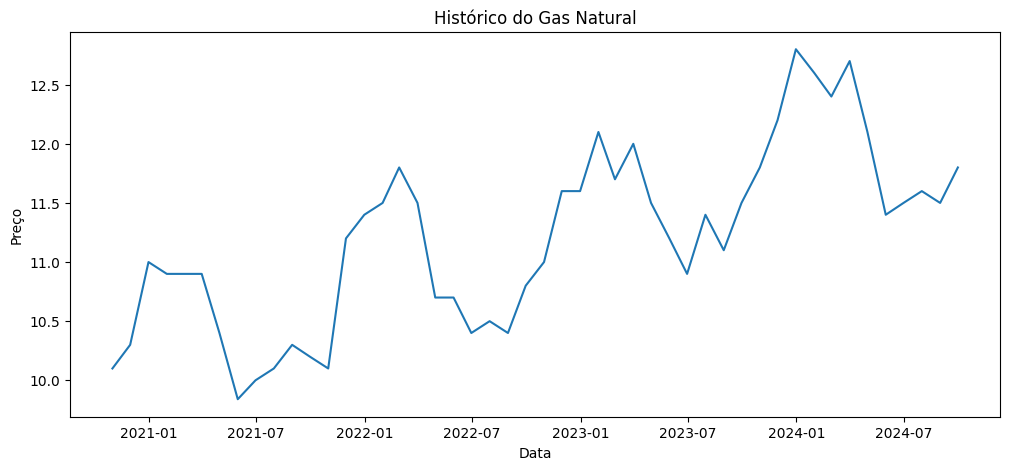

In [49]:
#DADOS ESRTRAIDO  E PLOTADO
aquivo_gas_natural['Dates']=pd.to_datetime(aquivo_gas_natural['Dates'], format='%m/%d/%y')
aquivo_gas_natural['Prices']=aquivo_gas_natural['Prices'].astype(float)
#plotar o grafico
plt.figure(figsize=(12,5))
plt.plot(aquivo_gas_natural['Dates'],aquivo_gas_natural['Prices'])
plt.title('Histórico do Gas Natural')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.show()


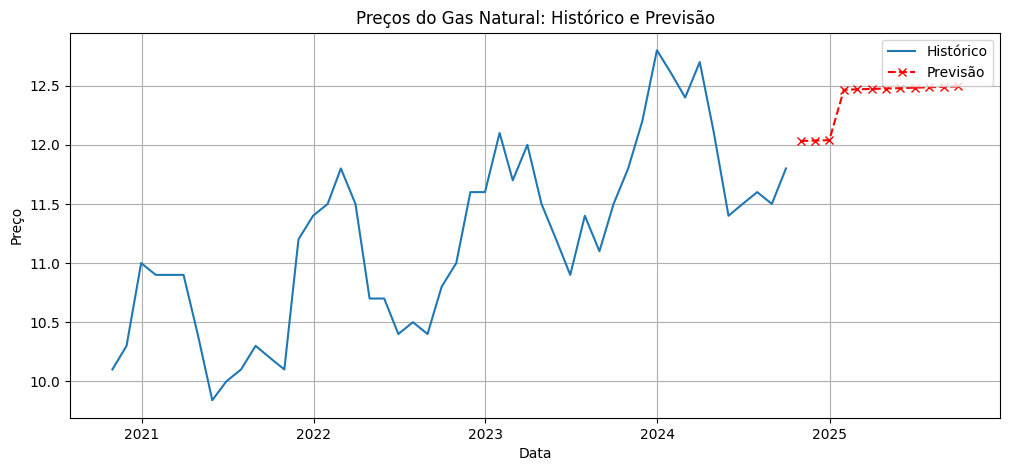

Preço estimado para 2023-09-01 : 11.91
Preço estimado para 2025-09-01 : 12.84


In [53]:
from sklearn.linear_model import LinearRegression

# PREPARANDO ARQUIVO E SEUS DIRETORES PARA VALIDAÇÃO DO MODELO
aquivo_gas_natural['Month'] = aquivo_gas_natural['Dates'].dt.month
aquivo_gas_natural['TimeIndex'] = np.arange(len(aquivo_gas_natural))

# DEFININDO AS VARIAVEIS PARA O TREINO
X = pd.DataFrame({
    'TimeIndex': aquivo_gas_natural['TimeIndex'],
    'Month': aquivo_gas_natural['Month']
})
y = aquivo_gas_natural['Prices']

# INICIANDO O MODELO DE REGRESSÃO
model = LinearRegression()
model.fit(X, y)

#FUNÇÃ PARA ESTIMAR QUALQUER DATA
def estimar_preco(data_str):
  data=pd.to_datetime(data_str)
  meses_passados=(data.year-aquivo_gas_natural['Dates'].dt.year.min())*12+(data.month-aquivo_gas_natural['Dates'].dt.month.min())
  X_pred=pd.DataFrame({'TimeIndex':[meses_passados],'Month':[data.month]})
  preco=model.predict(X_pred)[0]
  return round(preco,2)

#ESTRAPOLAR PARA MAIS 12 MESES
future_dates=pd.date_range(start=aquivo_gas_natural['Dates'].max()+pd.offsets.MonthEnd(1),periods=12,freq='ME')
future_index=np.arange(len(aquivo_gas_natural),len(aquivo_gas_natural)+12)
future_months=future_dates.month
X_future=pd.DataFrame({'TimeIndex':future_index,'Month':future_months})
future_prices=model.predict(X_future)

#GRAFICO DE HISTÓRICO + PREVISÃO
plt.figure(figsize=(12,5))
plt.plot(aquivo_gas_natural['Dates'],aquivo_gas_natural['Prices'],label='Histórico')
plt.plot(future_dates,future_prices,marker='x',linestyle='--',color='red',label='Previsão')
plt.title('Preços do Gas Natural: Histórico e Previsão')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.legend()
plt.grid(True)
plt.show()

# PREÇO ESTIMADO
data_str='2023-09-01'
preco_estimado=estimar_preco(data_str)
print('Preço estimado para',data_str,':',preco_estimado)

data_str='2025-09-01'
preco_estimado=estimar_preco(data_str)
print('Preço estimado para',data_str,':',preco_estimado)

Média dos preços dos últimos 12 meses: 11.207083333333332


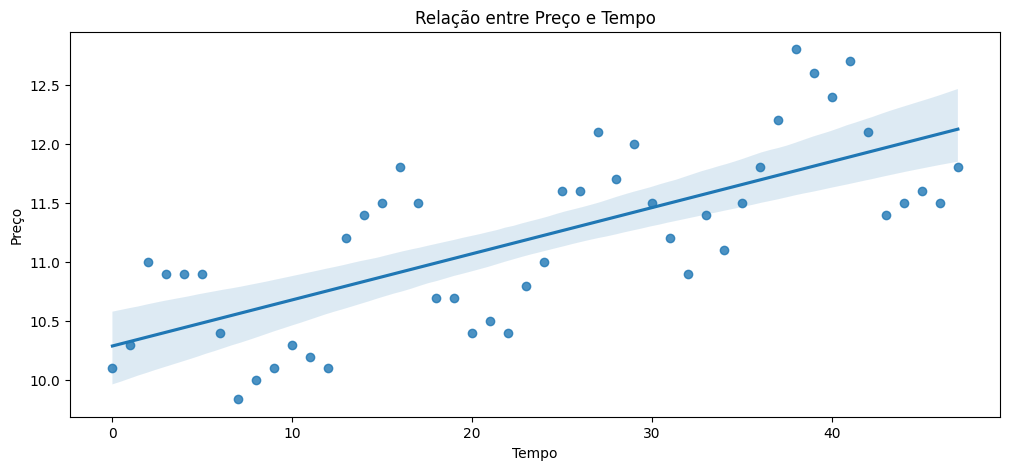

Coeficiente de correlação de Pearson: 0.7206588580458765


In [40]:
#MEDIA DOS PREÇOS AOS TEMPO HISTORICO
media_historica=aquivo_gas_natural['Prices'].mean()
print('Média dos preços dos últimos 12 meses:',media_historica)

#grafico correlação
plt.figure(figsize=(12,5))
sns.regplot(x='TimeIndex',y='Prices',data=aquivo_gas_natural)
plt.title('Relação entre Preço e Tempo')
plt.xlabel('Tempo')
plt.ylabel('Preço')
plt.show()

print('Coeficiente de correlação de Pearson:',aquivo_gas_natural['TimeIndex'].corr(aquivo_gas_natural['Prices']))


Coeficiente de correlação de Pearson: 0.7208301816364159


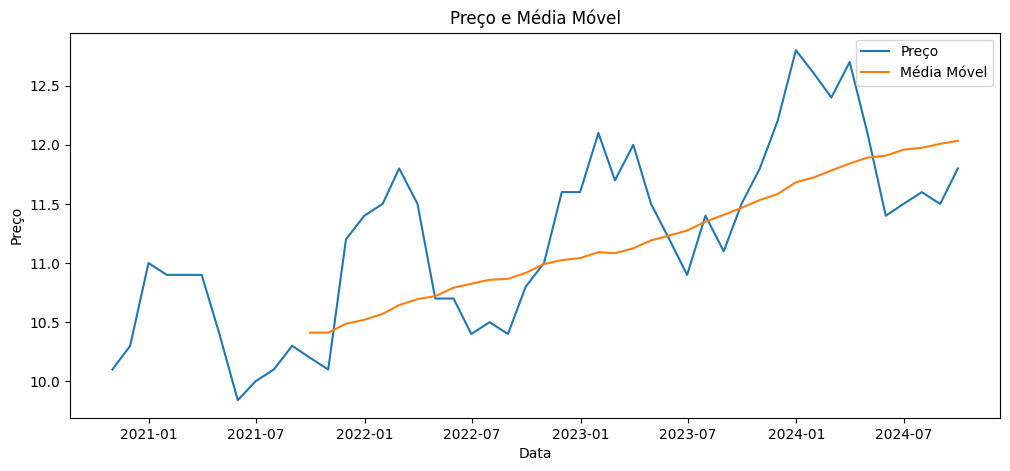

In [43]:
#   fazendo a media movel  por teste
aquivo_gas_natural['MediaMovel']=aquivo_gas_natural['Prices'].rolling(window=12).mean()
plt.figure(figsize=(12,5))
plt.plot(aquivo_gas_natural['Dates'],aquivo_gas_natural['Prices'],label='Preço')
plt.plot(aquivo_gas_natural['Dates'],aquivo_gas_natural['MediaMovel'],label='Média Móvel')
plt.title('Preço e Média Móvel')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.legend()

print('Coeficiente de correlação de Pearson:',aquivo_gas_natural['Dates'].corr(aquivo_gas_natural['Prices']))

